# Data Cleaning

**Goal:** Turn raw, messy data into a clean, model-ready DataFrame — handling missing values, outliers, wrong dtypes, and duplicates.

**Why it matters:** Models don't fail because the algorithm is wrong. They fail because the data is dirty. Garbage in → garbage out. This notebook shows the *decision process*, not just the code.

**Dataset:** Titanic (same as before)

**Prerequisite:** [01-pandas-basics.ipynb](./01-pandas-basics.ipynb)

---

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Nicer default plots
sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (10, 5)

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [148]:

baseline = {
    "rows": df.shape[0],
    "columns": df.shape[1],
    "missing_total": df.isnull().sum().sum(),
    "duplicates": df.duplicated().sum(),
}
baseline

{'rows': 891,
 'columns': 12,
 'missing_total': np.int64(866),
 'duplicates': np.int64(0)}

In [149]:
missing = pd.DataFrame({
    "count": df.isnull().sum(),
    "percent": (df.isnull().sum() / len(df) * 100).round(2),
})
missing = missing[missing["count"] > 0].sort_values("percent", ascending=False)
missing

,count,percent
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


##  Cabin — Drop or Keep?

High missing rate ≠ useless. Check if presence of `Cabin` correlates with survival. If yes, convert to a binary `HasCabin` feature.

In [150]:

df["HasCabin"] = df["Cabin"].notna().astype(int)

print(df.groupby("HasCabin")["Survived"].mean().round(3))

HasCabin
0    0.300
1    0.667
Name: Survived, dtype: float64


In [151]:

df = df.drop(columns=["Cabin"])
print("Columns now:", df.columns.tolist())

Columns now: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked', 'HasCabin']


## 4. Imputing Age

`Age` has ~20٪ missing. Median is safer than mean (age distribution is slightly right-skewed).  
**But:** imputing with a single value loses information. Better → impute **by group** (e.g., by `Pclass` and `Sex`).

In [152]:

df["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [153]:

median_age = df.groupby(["Pclass", "Sex"])["Age"].median()
print(median_age)

Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64


In [154]:
# df["Age"] = df["Age"].fillna(df["Age"].median())
df["Age"] = df.groupby(["Pclass", "Sex"])["Age"].transform(
    lambda x: x.fillna(x.median())
)
print("Remaining Age NaN:", df["Age"].isnull().sum())


Remaining Age NaN: 0


##  Embarked — Fill with Mode

Only 2 values missing. Fill with the most frequent port.

In [155]:
print("Before:", df["Embarked"].isnull().sum())
print("Mode:", df["Embarked"].mode()[0])

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
print("After :", df["Embarked"].isnull().sum())

Before: 2
Mode: S
After : 0


## Fixing Wrong Dtypes

`Pclass` is a category, not a number — 1st/2nd/3rd class aren't "more" or "less". Same for `Survived`.

In [156]:
df["Pclass"] = df["Pclass"].astype("category")
df["Pclass"]
df["Survived"] = df["Survived"].astype("category")
df["Sex"] = df["Sex"].astype("category")
df["Embarked"] = df["Embarked"].astype("category")

##  Duplicates

Check for fully duplicated rows. If any, drop them.

In [157]:
dupes = df.duplicated().sum()
print("Duplicate rows:", dupes)
if dupes > 0 :
  df = df.drop_duplicates().reset_index(drop=True)
  print("After drop:", df.shape)


Duplicate rows: 0


##  Outliers — Detect, Don't Blindly Remove

Use the **IQR method**: values outside `[Q1 - 1.5·IQR, Q3 + 1.5·IQR]` are potential outliers.  
**Rule:** investigate before removing. Some outliers are signal, not noise.

In [158]:
def iqr_outliers(series):
  q1 , q3 = series.quantile([0.25,0.75])
  iqr = q3 - q1
  lower , upper = q1 - 1.5 * iqr , q3 + 1.5 * iqr
  return(series < lower) | (series > upper) , lower , upper

mask , lo , hi = iqr_outliers(df["Fare"])
print(f"Fare bounds: [{lo:.2f}, {hi:.2f}]")
print(f"Outliers   : {mask.sum()} ({mask.mean()*100:.1f}%)")



Fare bounds: [-26.72, 65.63]
Outliers   : 116 (13.0%)


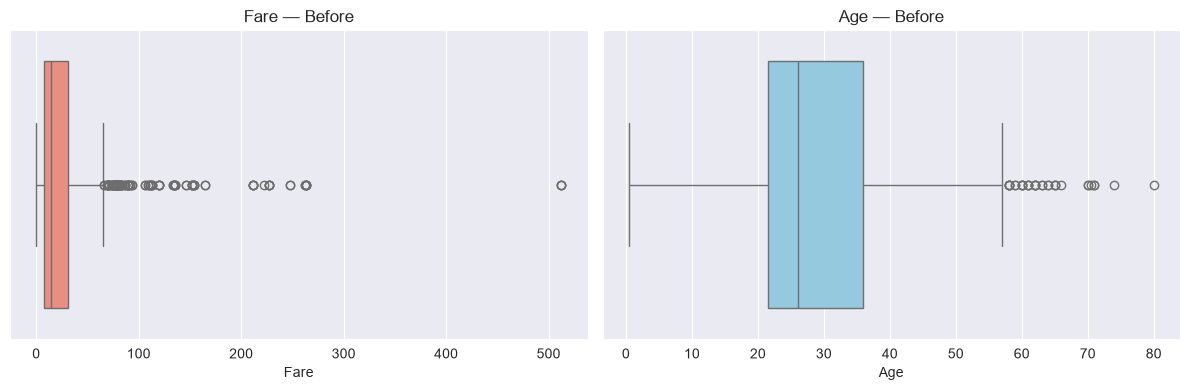

In [159]:
# Visualize — boxplot makes outliers obvious
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df["Fare"], ax=axes[0], color="salmon")
axes[0].set_title("Fare — Before")

sns.boxplot(x=df["Age"], ax=axes[1], color="skyblue")
axes[1].set_title("Age — Before")
plt.tight_layout()
plt.show()

##  Log Transform for Skewed Features

`Fare` is heavily right-skewed. Log transform compresses the tail — often helps linear models.

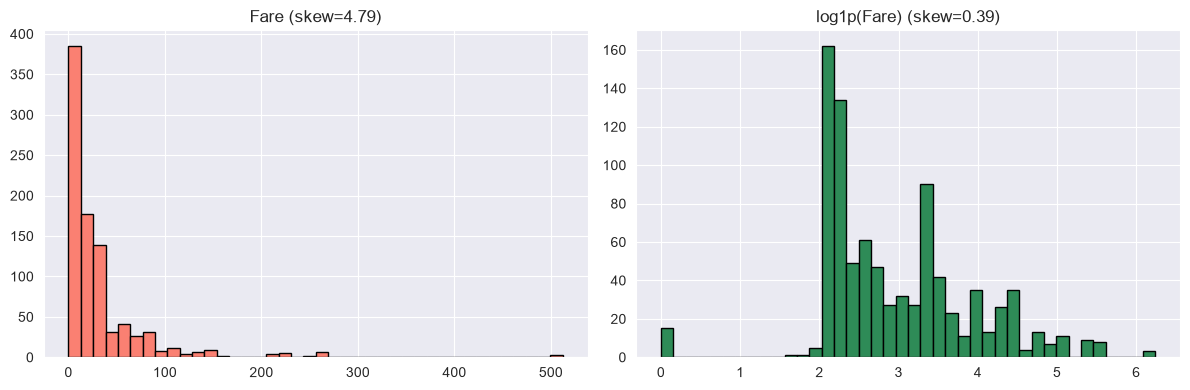

In [160]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["Fare"].hist(ax=axes[0], bins=40, color="salmon", edgecolor="black")
axes[0].set_title(f"Fare (skew={df['Fare'].skew():.2f})")

# log1p  safe for zeros
df["Fare_log"] = np.log1p(df["Fare"])
df["Fare_log"].hist(ax=axes[1], bins=40, color="seagreen", edgecolor="black")
axes[1].set_title(f"log1p(Fare) (skew={df['Fare_log'].skew():.2f})")

plt.tight_layout()
plt.show()

In [161]:
final = {
    "rows": df.shape[0],
    "columns": df.shape[1],
    "missing_total": df.isnull().sum().sum(),
    "duplicates": df.duplicated().sum(),
}
comparison = pd.DataFrame({"before": baseline, "after": final})
# comparison["delta"] = comparison["after"] - comparison["before"]
comparison



,before,after
rows,891,891
columns,12,13
missing_total,866,0
duplicates,0,0


In [162]:
df.to_csv("titanic_clean.csv", index=False)
print("Saved: titanic_clean.csv")
print("Final shape:", df.shape)

Saved: titanic_clean.csv
Final shape: (891, 13)


## 11. Summary of Decisions

| Column | Problem | Decision | Reason |
|---|---|---|---|
| `Cabin` | 77٪ missing | Drop column, keep `HasCabin` | Too sparse, but presence correlates with survival |
| `Age` | 20٪ missing | Impute by (Pclass, Sex) median | Preserves group-level structure |
| `Embarked` | 2 missing | Fill with mode | Negligible, mode is safe |
| `Pclass`, `Sex`, `Embarked`, `Survived` | Wrong dtype | Convert to `category` | They're not ordinal numbers |
| `Fare` | Right-skewed | `log1p` transform | Compresses tail for linear models |
| Outliers | Present in `Fare` | **Keep** | High fare is real signal, not error |

## 🚀 Next

→ [03-visualization.ipynb](./03-visualization.ipynb): turn this cleaned data into insights.